In [ ]:
import os, sys, subprocess

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    BASE_DIR = '/content/VisionAI'
    if not os.path.exists(BASE_DIR):
        subprocess.run(
            ['git', 'clone', '-b', 'ML',
             'https://github.com/SINCER-Ali/VisionAI.git', BASE_DIR],
            check=True
        )
    try:
        import vision_ai
    except ImportError:
        subprocess.run(['pip', 'install', 'maturin', '-q'], check=True)
        subprocess.run(['maturin', 'develop', '--release'],
                       cwd=f'{BASE_DIR}/python_binding', check=True)
else:
    BASE_DIR = r'C:\VisionAI'

BINDING_DIR = os.path.join(BASE_DIR, 'python_binding')
DATASET_DIR = os.path.join(BASE_DIR, 'datasets')
DATASET_TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
sys.path.insert(0, BINDING_DIR)

import vision_ai
print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"BASE_DIR      : {BASE_DIR}")


In [2]:
model = vision_ai.PyMLP([4, 8, 3])

input_test = [0.1, 0.2, 0.3, 0.4]
result = model.predict(input_test)
print("Prédiction:", result)
print("Somme des probabilités:", sum(result))


Prédiction: [0.3412381716610184, 0.30826382830359494, 0.3504980000353866]
Somme des probabilités: 1.0


In [4]:
import matplotlib.pyplot as plt

model = vision_ai.PyMLP([2, 8, 3])

inputs = [[0.1, 0.2], [0.4, 0.5], [0.8, 0.9], [0.2, 0.3]]
targets = [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [1.0, 0.0, 0.0]]

model.train(inputs, targets, 0.01, 200)

print("Entrainement termine !")
for i, inp in enumerate(inputs):
    pred = model.predict(inp)
    print(f"Input {inp} -> Prediction: {[round(p, 3) for p in pred]}")

Entrainement termine !
Input [0.1, 0.2] -> Prediction: [0.55, 0.265, 0.184]
Input [0.4, 0.5] -> Prediction: [0.441, 0.26, 0.299]
Input [0.8, 0.9] -> Prediction: [0.286, 0.219, 0.495]
Input [0.2, 0.3] -> Prediction: [0.516, 0.266, 0.219]


Epoque 1/10 - Loss: 1.0537
Epoque 2/10 - Loss: 0.9164
Epoque 3/10 - Loss: 0.6873
Epoque 4/10 - Loss: 0.7143
Epoque 5/10 - Loss: 0.7142
Epoque 6/10 - Loss: 0.7143
Epoque 7/10 - Loss: 0.8818
Epoque 8/10 - Loss: 0.9028
Epoque 9/10 - Loss: 0.7143
Epoque 10/10 - Loss: 0.7143


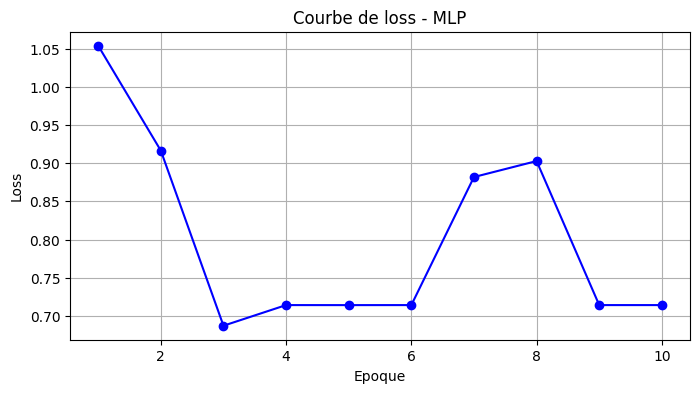

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.load(os.path.join(DATASET_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATASET_DIR, "y_train.npy"))
X_test = np.load(os.path.join(DATASET_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATASET_DIR, "y_test.npy"))

CLASSES = ["aucun", "humain", "animal"]

inputs_train = [X_train[i].tolist() for i in range(len(X_train))]
targets_train = []
for label in y_train:
    t = [0.0, 0.0, 0.0]
    t[int(label)] = 1.0
    targets_train.append(t)

losses = []
model = vision_ai.PyMLP([12288, 64, 3])

for epoch in range(10):
    model.train(inputs_train, targets_train, 0.001, 1)
    preds = [model.predict(x) for x in inputs_train]
    loss = sum(
        sum((p - t)**2 for p, t in zip(pred, target))
        for pred, target in zip(preds, targets_train)
    ) / len(inputs_train)
    losses.append(loss)
    print(f"Epoque {epoch+1}/10 - Loss: {loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), losses, marker='o', color='blue')
plt.title("Courbe de loss - MLP")
plt.xlabel("Epoque")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Accuracy : 70.2%


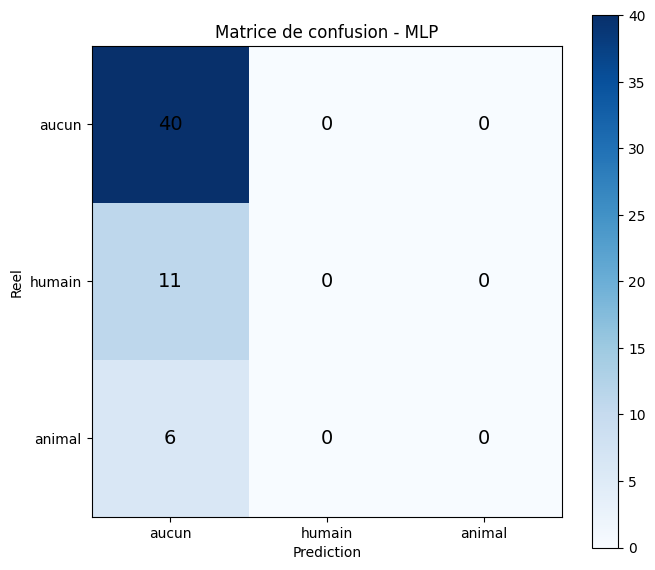

In [3]:
from sklearn.metrics import confusion_matrix

inputs_test = [X_test[i].tolist() for i in range(len(X_test))]
predictions = [model.predict(x) for x in inputs_test]
y_pred = [pred.index(max(pred)) for pred in predictions]

correct = sum(1 for p, t in zip(y_pred, y_test) if p == int(t))
accuracy = correct / len(y_test) * 100
print(f"Accuracy : {accuracy:.1f}%")

cm = confusion_matrix(y_test.astype(int), y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prediction")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion - MLP")

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

Re-entrainement avec plus d'epoques...
Termine !
Accuracy avec 50 epoques : 70.2%


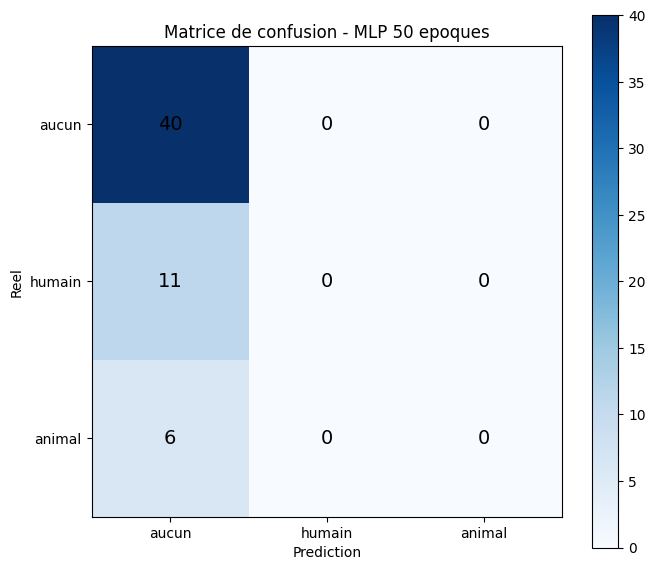

In [6]:
print("Re-entrainement avec plus d'epoques...")
model2 = vision_ai.PyMLP([12288, 64, 3])
model2.train(inputs_train, targets_train, 0.001, 50)
print("Termine !")

predictions2 = [model2.predict(x) for x in inputs_test]
y_pred2 = [pred.index(max(pred)) for pred in predictions2]

correct2 = sum(1 for p, t in zip(y_pred2, y_test) if p == int(t))
accuracy2 = correct2 / len(y_test) * 100
print(f"Accuracy avec 50 epoques : {accuracy2:.1f}%")

cm2 = confusion_matrix(y_test.astype(int), y_pred2)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm2, cmap="Blues")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prediction")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion - MLP 50 epoques")

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm2[i, j]), ha="center", va="center", color="black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

Comparaison de differents learning rates...


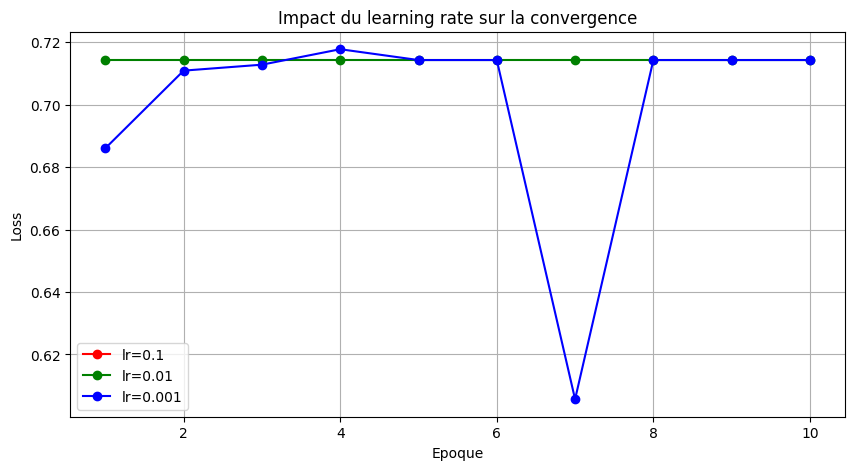

In [7]:
print("Comparaison de differents learning rates...")

learning_rates = [0.1, 0.01, 0.001]
colors = ['red', 'green', 'blue']
all_losses = []

for lr in learning_rates:
    m = vision_ai.PyMLP([12288, 64, 3])
    lr_losses = []
    for epoch in range(10):
        m.train(inputs_train, targets_train, lr, 1)
        preds = [m.predict(x) for x in inputs_train]
        loss = sum(
            sum((p - t)**2 for p, t in zip(pred, target))
            for pred, target in zip(preds, targets_train)
        ) / len(inputs_train)
        lr_losses.append(loss)
    all_losses.append(lr_losses)

plt.figure(figsize=(10, 5))
for i, lr in enumerate(learning_rates):
    plt.plot(range(1, 11), all_losses[i], marker='o', color=colors[i], label=f'lr={lr}')
plt.title("Impact du learning rate sur la convergence")
plt.xlabel("Epoque")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()